In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data_steps") / "csv"

# ac = pd.read_csv(DATA_DIR / "nhanes_1440_AC.csv")
# log10_ac = pd.read_csv(DATA_DIR / "nhanes_1440_log10AC.csv")
# mims = pd.read_csv(DATA_DIR / "nhanes_1440_PAXMTSM.csv")
# log10_mims = pd.read_csv(DATA_DIR / "nhanes_1440_log10PAXMTSM.csv")
paxpredm = pd.read_csv(DATA_DIR / "nhanes_1440_PAXPREDM.csv")
# troiano_wear = pd.read_csv(DATA_DIR / "nhanes_1440_troianowear.csv")
paxflgsm = pd.read_csv(DATA_DIR / "nhanes_1440_PAXFLGSM.csv")
scsslsteps = pd.read_csv(DATA_DIR / "nhanes_1440_scsslsteps.csv")

In [2]:
import pandas as pd

id_cols = ["SEQN", "PAXDAYM", "PAXDAYWM"] # 요일(PAXDAYWM)도 ID에 포함

# 각 데이터프레임의 별칭(Prefix) 지정
data_info = [
    (paxpredm, "state"),
    (paxflgsm, "flag"),
    (scsslsteps, "step"),
]

# 첫 번째 데이터프레임 준비
df, prefix = data_info[0]
merged_df = df.rename(columns={c: f"{prefix}_{c}" for c in df.columns if c not in id_cols})

# 나머지 데이터프레임 순차 병합
for df, prefix in data_info[1:]:
    # 데이터 컬럼명 변경 (예: min_0001 -> step_min_0001)
    df_renamed = df.rename(columns={c: f"{prefix}_{c}" for c in df.columns if c not in id_cols})

    # 병합
    merged_df = pd.merge(merged_df, df_renamed, on=id_cols, how="inner")

merged_df.head()

,SEQN,PAXDAYM,PAXDAYWM,state_min_0001,state_min_0002,state_min_0003,state_min_0004,state_min_0005,state_min_0006,state_min_0007,...,step_min_1431,step_min_1432,step_min_1433,step_min_1434,step_min_1435,step_min_1436,step_min_1437,step_min_1438,step_min_1439,step_min_1440
0,73557,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,73557,2,4,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,73557,3,5,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,73557,4,6,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,73557,5,7,3.0,3.0,3.0,3.0,3.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
valid_steps = merged_df.copy()
for i in range(1, 1441):
    col_step = f"step_min_{i:04d}"
    col_state = f"state_min_{i:04d}"
    col_flag = f"flag_min_{i:04d}"
    
    # 조건: (깨어있음) AND (플래그 없음)
    condition = (valid_steps[col_state] == 1) & (valid_steps[col_flag] == False)
    
    # 조건을 만족하지 않으면 걸음수를 0으로 처리
    valid_steps.loc[~condition, col_step] = 0

# 'step_'으로 시작하는 모든 컬럼을 더함
step_cols = [c for c in valid_steps.columns if c.startswith("step_")]
valid_steps['daily_total_steps'] = valid_steps[step_cols].sum(axis=1)

user_avg_steps = valid_steps.groupby('SEQN')['daily_total_steps'].mean().reset_index()
user_avg_steps.columns = ['SEQN', 'avg_daily_steps']

### 걸음수 분포

C:\Users\user\AppData\Local\Temp\ipykernel_9000\2462297246.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_groups = user_avg_steps.dropna(subset=["age_group"]).groupby("age_group")


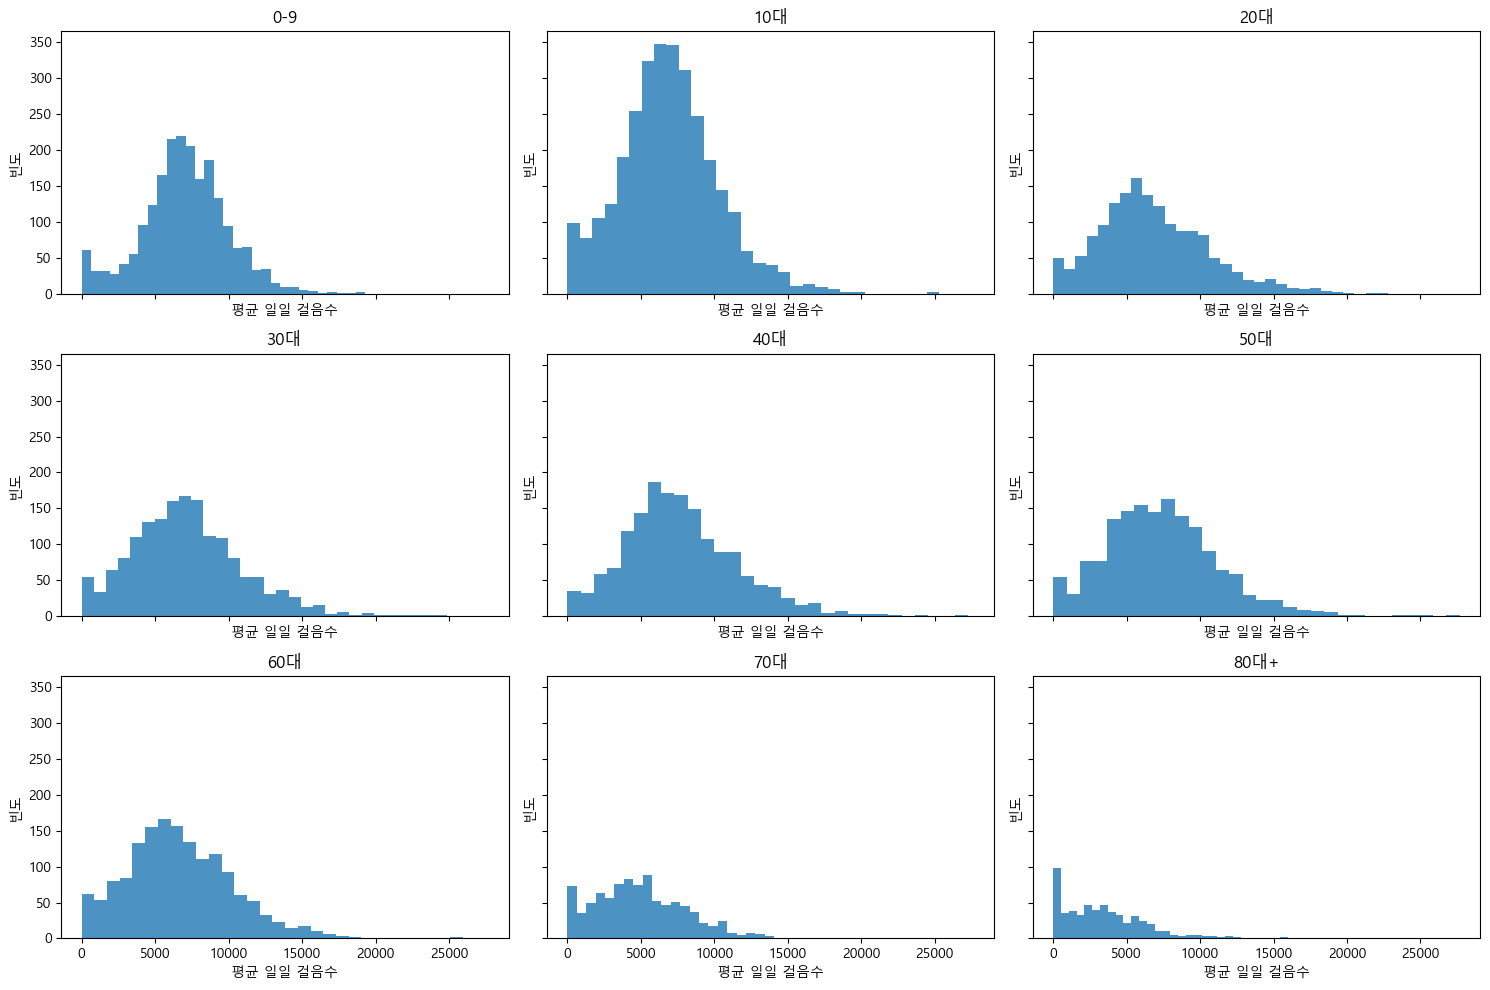

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

subject_info_path = Path("data_steps") / "subject-info.csv"
subject_info = pd.read_csv(subject_info_path)

age_col = "age_in_years_at_screening"
if age_col not in subject_info.columns:
    raise ValueError(f"연령 컬럼 {age_col}이(가) subject-info.csv에 없습니다.")

if age_col not in user_avg_steps.columns:
    user_avg_steps = user_avg_steps.merge(
        subject_info[["SEQN", age_col]],
        on="SEQN",
        how="inner",
    )

if age_col not in user_avg_steps.columns:
    age_col_x = f"{age_col}_x"
    age_col_y = f"{age_col}_y"
    if age_col_x in user_avg_steps.columns:
        user_avg_steps = user_avg_steps.rename(columns={age_col_x: age_col})
    elif age_col_y in user_avg_steps.columns:
        user_avg_steps = user_avg_steps.rename(columns={age_col_y: age_col})
    else:
        raise ValueError(f"연령 컬럼을 찾을 수 없습니다: {user_avg_steps.columns.tolist()}")

age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 200]
age_labels = ["0-9", "10대", "20대", "30대", "40대", "50대", "60대", "70대", "80대+"]
user_avg_steps["age_group"] = pd.cut(
    user_avg_steps[age_col],
    bins=age_bins,
    labels=age_labels,
    right=False,
)

age_groups = user_avg_steps.dropna(subset=["age_group"]).groupby("age_group")

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (group_name, group_df) in zip(axes, age_groups):
    ax.hist(group_df["avg_daily_steps"], bins=30, alpha=0.8)
    ax.set_title(str(group_name))
    ax.set_xlabel("평균 일일 걸음수")
    ax.set_ylabel("빈도")

plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path
import pandas as pd

AGE_TARGETS = {
    "child": 12000,
    "teen": 10000,
    "adult": 8000,
    "senior": 7000,
}

AGE_GROUP_TO_BRACKET = {
    "0-9": "child",
    "10대": "teen",
    "20대": "adult",
    "30대": "adult",
    "40대": "adult",
    "50대": "adult",
    "60대": "senior",
    "70대": "senior",
    "80대+": "senior",
}

subject_info_path = Path("data_steps") / "subject-info.csv"
subject_info = pd.read_csv(subject_info_path)

age_col = "age_in_years_at_screening"
if age_col not in subject_info.columns:
    raise ValueError(f"Missing age column in subject-info.csv: {age_col}")

if age_col not in user_avg_steps.columns:
    user_avg_steps = user_avg_steps.merge(
        subject_info[["SEQN", age_col]],
        on="SEQN",
        how="inner",
    )

if age_col not in user_avg_steps.columns:
    age_col_x = f"{age_col}_x"
    age_col_y = f"{age_col}_y"
    if age_col_x in user_avg_steps.columns:
        user_avg_steps = user_avg_steps.rename(columns={age_col_x: age_col})
    elif age_col_y in user_avg_steps.columns:
        user_avg_steps = user_avg_steps.rename(columns={age_col_y: age_col})
    else:
        raise ValueError(f"Age column not found after merge: {user_avg_steps.columns.tolist()}")

if "age_group" not in user_avg_steps.columns:
    age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 200]
    age_labels = ["0-9", "10대", "20대", "30대", "40대", "50대", "60대", "70대", "80대+"]
    user_avg_steps["age_group"] = pd.cut(
        user_avg_steps[age_col],
        bins=age_bins,
        labels=age_labels,
        right=False,
    )

user_avg_steps["age_bracket"] = user_avg_steps["age_group"].map(AGE_GROUP_TO_BRACKET)
if user_avg_steps["age_bracket"].isna().any():
    unknown_groups = sorted(user_avg_steps.loc[user_avg_steps["age_bracket"].isna(), "age_group"].dropna().astype(str).unique())
    raise ValueError(f"Unmapped age_group values found: {unknown_groups}")

user_avg_steps["target_steps"] = user_avg_steps["age_bracket"].map(AGE_TARGETS)

target_counts = user_avg_steps.groupby("age_group", observed=True)["target_steps"].nunique(dropna=True)
if (target_counts > 1).any():
    bad_groups = target_counts[target_counts > 1].to_dict()
    raise ValueError(f"Inconsistent target_steps within age_group: {bad_groups}")

percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

result_rows = []
for group_label, group_df in user_avg_steps.groupby("age_group", observed=True):
    if pd.isna(group_label):
        continue
    target = int(group_df["target_steps"].iloc[0])
    below_target = group_df[group_df["avg_daily_steps"] < target]["avg_daily_steps"]
    if below_target.empty:
        continue

    for p in percentiles:
        if p == 0:
            steps_value = float(target)
        else:
            steps_value = float(below_target.quantile(1 - p / 100))
        result_rows.append(
            {
                "age_group": group_label,
                "target_steps": float(target),
                "percentile": p,
                "steps_at_percentile": steps_value,
            }
        )

percentile_table = pd.DataFrame(result_rows)
percentile_table = percentile_table.sort_values(["age_group", "percentile"], ascending=[True, False])

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

percentile_table.head()



,age_group,target_steps,percentile,steps_at_percentile
10,0-9,12000.0,100,0.000000
9,0-9,12000.0,90,3328.777778
8,0-9,12000.0,80,4803.986667
7,0-9,12000.0,70,5633.266667
6,0-9,12000.0,60,6302.311111


### 음이항 분포 적합

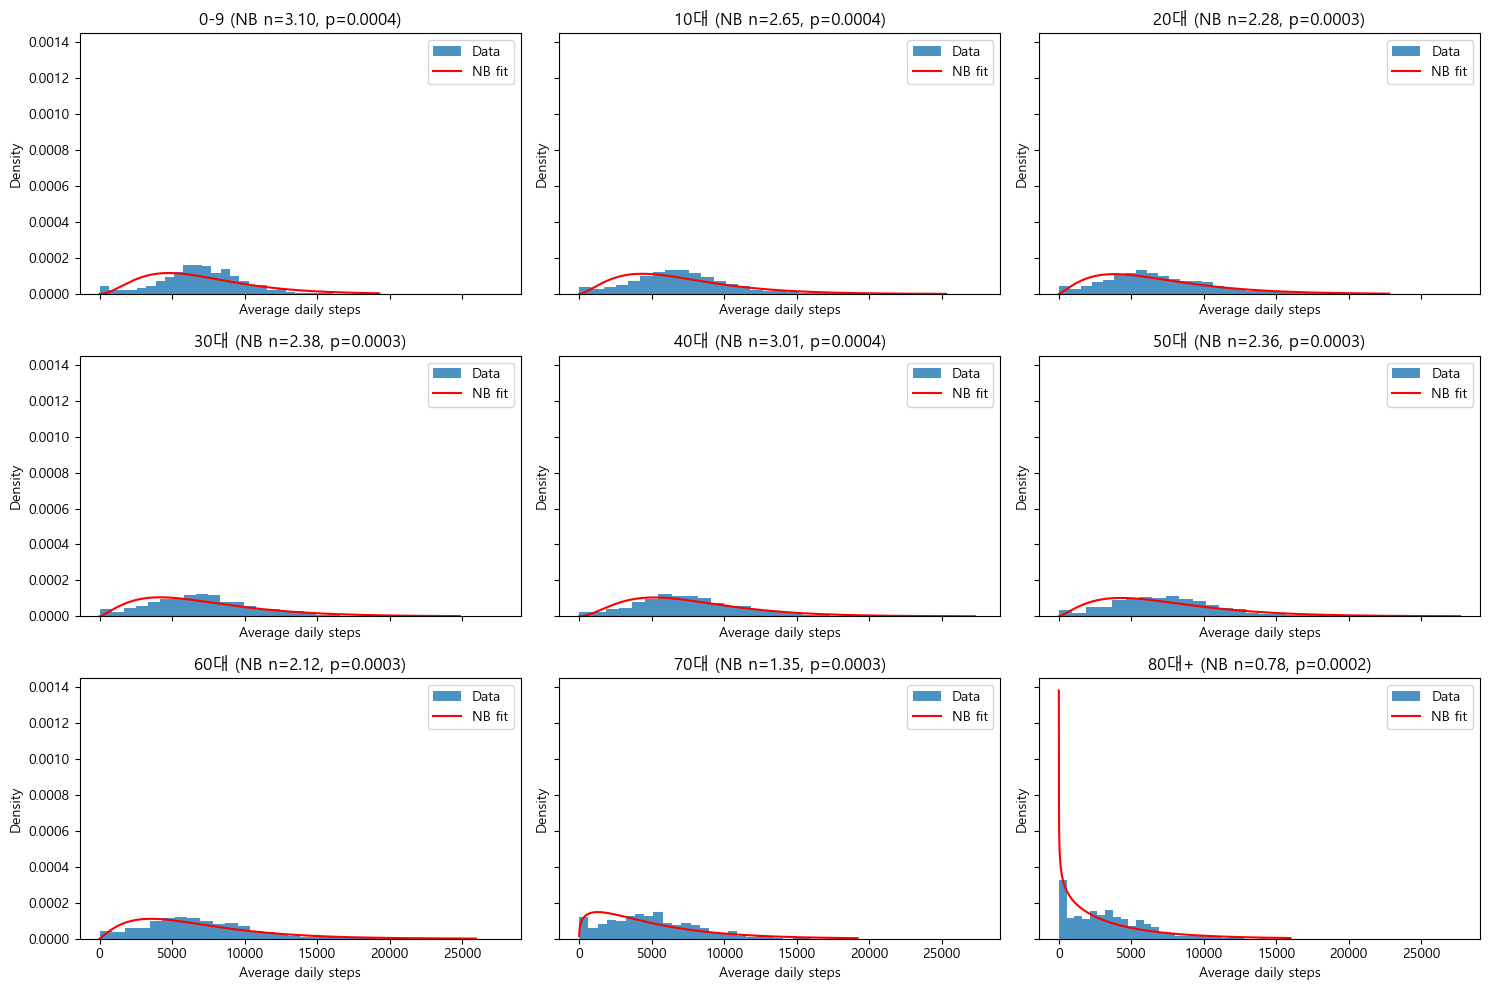

In [6]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt


def fit_nbinom_mle(data):
    """Estimate negative-binomial parameters (n, p) via MLE."""
    data = np.round(np.asarray(data)).astype(int)
    if data.size == 0:
        return None

    mean = data.mean()
    var = data.var()
    if var <= mean or mean <= 0:
        return None

    p_init = mean / var
    n_init = (mean ** 2) / (var - mean)

    def neg_log_likelihood(params):
        n, p = params
        if n <= 0 or p <= 0 or p >= 1:
            return 1e10
        return -np.sum(stats.nbinom.logpmf(data, n, p))

    res = minimize(
        neg_log_likelihood,
        [n_init, p_init],
        bounds=[(1e-5, None), (1e-5, 1 - 1e-5)],
    )

    if res.success:
        return res.x
    return n_init, p_init


def fit_count_distribution(data):
    """Fit NB when over-dispersed, otherwise fall back to Poisson."""
    data = np.round(np.asarray(data)).astype(int)
    if data.size == 0:
        return None

    mean = data.mean()
    var = data.var()

    if mean < 0:
        return None

    if var <= mean:
        return {
            "distribution": "poisson",
            "mu": float(mean),
            "fit_method": "Poisson fallback (var<=mean)",
        }

    fitted_nb = fit_nbinom_mle(data)
    if fitted_nb is None:
        return {
            "distribution": "poisson",
            "mu": float(mean),
            "fit_method": "Poisson fallback (NB fit failed)",
        }

    n, p = fitted_nb
    return {
        "distribution": "nbinom",
        "n": float(n),
        "p": float(p),
        "fit_method": "MLE(custom nbinom)",
    }


fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (group_name, group_df) in zip(axes, age_groups):
    steps_data = group_df["avg_daily_steps"].dropna()
    if len(steps_data) == 0:
        ax.set_title(f"{group_name} (No Data)")
        continue

    ax.hist(steps_data, bins=30, alpha=0.8, density=True, label="Data")
    fitted = fit_count_distribution(steps_data)

    x = np.arange(0, int(steps_data.max()) + 1)
    if fitted is None:
        ax.set_title(f"{group_name} (Fit Failed)")
    elif fitted["distribution"] == "nbinom":
        n = fitted["n"]
        p = fitted["p"]
        pmf_fitted = stats.nbinom.pmf(x, n, p)
        ax.plot(x, pmf_fitted, "r-", label="NB fit")
        ax.set_title(f"{group_name} (NB n={n:.2f}, p={p:.4f})")
    else:
        mu = fitted["mu"]
        pmf_fitted = stats.poisson.pmf(x, mu)
        ax.plot(x, pmf_fitted, "g-", label="Poisson fallback")
        ax.set_title(f"{group_name} (Poisson mu={mu:.2f})")

    ax.set_xlabel("Average daily steps")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()



In [7]:
# Refresh age_groups with target_steps included
age_groups = user_avg_steps.dropna(subset=["age_group"]).groupby("age_group", observed=True)

# Compute expected steps by deficit percentile from fitted count distribution
percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
mle_results = []

for group_name, group_df in age_groups:
    steps_data = group_df["avg_daily_steps"].dropna()
    if len(steps_data) == 0:
        continue

    fitted = fit_count_distribution(steps_data)
    if fitted is None:
        continue

    if "target_steps" not in group_df.columns:
        raise ValueError("target_steps is missing. Run the target calculation cell first.")

    target_candidates = group_df["target_steps"].dropna().unique()
    if len(target_candidates) != 1:
        raise ValueError(f"Inconsistent target_steps in group {group_name}: {target_candidates}")
    target = int(target_candidates[0])

    if fitted["distribution"] == "nbinom":
        n = fitted["n"]
        p = fitted["p"]
        cdf_at_target = float(stats.nbinom.cdf(target, n, p))
        ppf_fn = lambda q: stats.nbinom.ppf(q, n, p)
        param_n = float(n)
        param_p = float(p)
        param_mu = np.nan
    else:
        mu = fitted["mu"]
        cdf_at_target = float(stats.poisson.cdf(target, mu))
        ppf_fn = lambda q: stats.poisson.ppf(q, mu)
        param_n = np.nan
        param_p = np.nan
        param_mu = float(mu)

    for pct in percentiles:
        if pct == 0:
            val = target
        else:
            target_prob = (1 - pct / 100) * cdf_at_target
            target_prob = max(target_prob, np.finfo(float).eps)
            val = int(ppf_fn(target_prob))
            val = max(0, val)

        mle_results.append(
            {
                "age_group": group_name,
                "target_steps": target,
                "percentile": pct,
                "steps_at_percentile": val,
                "distribution": fitted["distribution"],
                "fit_method": fitted["fit_method"],
                "param_n": param_n,
                "param_p": param_p,
                "param_mu": param_mu,
                "sample_size": int(len(steps_data)),
            }
        )

mle_percentile_table = pd.DataFrame(mle_results)
pd.set_option("display.max_rows", None)

print("### Expected steps by deficit percentile (NB + Poisson fallback) ###")
display(mle_percentile_table)



### Expected steps by deficit percentile (NB + Poisson fallback) ###


,age_group,target_steps,percentile,steps_at_percentile,distribution,fit_method,param_n,param_p,param_mu,sample_size
0,0-9,12000,0,12000,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
1,0-9,12000,10,9975,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
2,0-9,12000,20,8603,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
3,0-9,12000,30,7525,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
4,0-9,12000,40,6607,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
5,0-9,12000,50,5783,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
6,0-9,12000,60,5007,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
7,0-9,12000,70,4244,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
8,0-9,12000,80,3444,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095
9,0-9,12000,90,2508,nbinom,MLE(custom nbinom),3.102492,0.000441,NaN,2095


In [ ]:
import os
import json
import numpy as np
import pandas as pd

if "mle_percentile_table" not in globals():
    raise ValueError("mle_percentile_table is missing. Run the percentile generation cell first.")
if "user_avg_steps" not in globals():
    raise ValueError("user_avg_steps is missing.")

required_cols = ["distribution", "fit_method", "param_n", "param_p", "param_mu", "sample_size"]
missing_cols = [c for c in required_cols if c not in mle_percentile_table.columns]
if missing_cols:
    raise ValueError(f"mle_percentile_table is missing columns: {missing_cols}. Re-run the previous cell.")

std_cols = [
    "source_notebook",
    "domain",
    "distribution",
    "age_group",
    "percentile",
    "target_steps",
    "percentile_value",
    "value_column",
    "param_s",
    "param_n",
    "param_p",
    "param_mu",
    "param_shape",
    "param_loc",
    "param_scale",
    "sample_size",
    "fit_method",
    "fit_params",
    "notes",
]

rows = mle_percentile_table.copy()
rows = rows.rename(columns={"steps_at_percentile": "percentile_value"})

rows["source_notebook"] = "DB_step.ipynb"
rows["domain"] = "step"
rows["value_column"] = "steps_at_percentile"
rows["param_s"] = pd.NA
rows["param_shape"] = pd.NA
rows["param_loc"] = pd.NA
rows["param_scale"] = pd.NA
rows["notes"] = "Expected steps by deficit percentile with NB + Poisson fallback"

def build_fit_params(row):
    if row["distribution"] == "nbinom":
        return json.dumps(
            {
                "n": None if pd.isna(row["param_n"]) else float(row["param_n"]),
                "p": None if pd.isna(row["param_p"]) else float(row["param_p"]),
            },
            ensure_ascii=False,
        )
    if row["distribution"] == "poisson":
        return json.dumps(
            {"mu": None if pd.isna(row["param_mu"]) else float(row["param_mu"])},
            ensure_ascii=False,
        )
    return json.dumps({}, ensure_ascii=False)

rows["fit_params"] = rows.apply(build_fit_params, axis=1)
rows = rows[std_cols]

output_path = "percentile.csv"
if os.path.exists(output_path):
    existing = pd.read_csv(output_path)
else:
    existing = pd.DataFrame(columns=std_cols)

for col in std_cols:
    if col not in existing.columns:
        existing[col] = pd.NA

cleanup_mask = (existing["domain"] == "step") & (existing["distribution"].isin(["nbinom", "poisson"]))
existing = existing[~cleanup_mask].copy()

result = pd.concat([existing[std_cols], rows], ignore_index=True)
result = result.sort_values(["domain", "distribution", "age_group", "percentile"], kind="stable").reset_index(drop=True)
result.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Saved percentile table to: {os.path.abspath(output_path)}")
print("step rows written:", len(rows))
print("distribution counts:")
print(rows["distribution"].value_counts(dropna=False))

Saved percentile table to: c:\Users\user\Documents\Projects_src\DB\percentile.csv
step rows written: 99
distribution counts:
distribution
nbinom    99
Name: count, dtype: int64
